In [505]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('darkgrid')
sns.set_palette('muted')

1. Data Loading & Exploration

In [ ]:
# Loaded 2019.csv into a DataFrame.
df=pd.read_csv('2019.csv')
df.head(10)

,Overall rank,Country or region,Score,GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption
0,1,Finland,7.769,1.340,1.587,0.986,0.596,0.153,0.393
1,2,Denmark,7.600,1.383,1.573,0.996,0.592,0.252,0.410
2,3,Norway,7.554,1.488,1.582,1.028,0.603,0.271,0.341
3,4,Iceland,7.494,1.380,1.624,1.026,0.591,0.354,0.118
4,5,Netherlands,7.488,1.396,1.522,0.999,0.557,0.322,0.298
5,6,Switzerland,7.480,1.452,1.526,1.052,0.572,0.263,0.343
6,7,Sweden,7.343,1.387,1.487,1.009,0.574,0.267,0.373
7,8,New Zealand,7.307,1.303,1.557,1.026,0.585,0.330,0.380
8,9,Canada,7.278,1.365,1.505,1.039,0.584,0.285,0.308
9,10,Austria,7.246,1.376,1.475,1.016,0.532,0.244,0.226


In [507]:
df.shape

(156, 9)

In [ ]:
# How many countries are in the dataset
df['Country or region'].nunique()

156

In [ ]:
df.columns

#What does each column represent?
# Overall rank - Rank of country 
# Country or region - Name of the country
# Score - Happiness score (0 to 10 scale)
# GDP per capita - Money/wealth level of people in the country
# Social support - Whether people have someone to help them in tough times
# Healthy life expectancy - How long people live a healthy life
# Freedom to make life choices - How free people feel to make their own decisions
# Generosity - How kind and helpful people are
# Perceptions of corruption - How corrupt people think their government/business is

Index(['Overall rank', 'Country or region', 'Score', 'GDP per capita',
       'Social support', 'Healthy life expectancy',
       'Freedom to make life choices', 'Generosity',
       'Perceptions of corruption'],
      dtype='object')

In [ ]:
df.isnull().sum()
# there are No null valuse 

Overall rank                    0
Country or region               0
Score                           0
GDP per capita                  0
Social support                  0
Healthy life expectancy         0
Freedom to make life choices    0
Generosity                      0
Perceptions of corruption       0
dtype: int64

In [ ]:
df.duplicated().sum()
# No duplicates

np.int64(0)

In [512]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 156 entries, 0 to 155
Data columns (total 9 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Overall rank                  156 non-null    int64  
 1   Country or region             156 non-null    object 
 2   Score                         156 non-null    float64
 3   GDP per capita                156 non-null    float64
 4   Social support                156 non-null    float64
 5   Healthy life expectancy       156 non-null    float64
 6   Freedom to make life choices  156 non-null    float64
 7   Generosity                    156 non-null    float64
 8   Perceptions of corruption     156 non-null    float64
dtypes: float64(7), int64(1), object(1)
memory usage: 11.1+ KB


In [ ]:
df.describe()
# The data shows that the average happiness score is around 5.4, indicating moderate global happiness levels.

,Overall rank,Score,GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption
count,156.000000,156.000000,156.000000,156.000000,156.000000,156.000000,156.000000,156.000000
mean,78.500000,5.407096,0.905147,1.208814,0.725244,0.392571,0.184846,0.110603
std,45.177428,1.113120,0.398389,0.299191,0.242124,0.143289,0.095254,0.094538
min,1.000000,2.853000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,39.750000,4.544500,0.602750,1.055750,0.547750,0.308000,0.108750,0.047000
50%,78.500000,5.379500,0.960000,1.271500,0.789000,0.417000,0.177500,0.085500
75%,117.250000,6.184500,1.232500,1.452500,0.881750,0.507250,0.248250,0.141250
max,156.000000,7.769000,1.684000,1.624000,1.141000,0.631000,0.566000,0.453000


In [ ]:
df.rename(columns={'Overall rank':'Rank','Country or region':'Country'},inplace=True)

2. Ranking & Filtering

In [ ]:
# Which are the top 10 happiest countries? 
df[['Country']].head(10)#this is happend because dataset is already Sorted
# or if not sorted in dataset
# sorted_df=df.sort_values(by='Score',ascending=False)
# top_10=sorted_df[['Rank','Country']].head(10)
# top_10

,Rank,Country
0,1,Finland
1,2,Denmark
2,3,Norway
3,4,Iceland
4,5,Netherlands
5,6,Switzerland
6,7,Sweden
7,8,New Zealand
8,9,Canada
9,10,Austria


In [ ]:
# Which are the bottom 10 unhappiest countries?
df[['Rank','Country']].tail(10)#Same sorted
# Or if not sorted 
# bottom_10=sorted_df[['Rank','Country']].tail(10)
# bottom_10

,Rank,Country
146,147,Haiti
147,148,Botswana
148,149,Syria
149,150,Malawi
150,151,Yemen
151,152,Rwanda
152,153,Tanzania
153,154,Afghanistan
154,155,Central African Republic
155,156,South Sudan


In [517]:
# Which countries have a GDP per capita above 1.4?
df[df['GDP per capita']>1.4]['Country']

2                   Norway
5              Switzerland
13              Luxembourg
15                 Ireland
18           United States
20    United Arab Emirates
27            Saudi Arabia
28                   Qatar
33               Singapore
50                  Kuwait
75               Hong Kong
Name: Country, dtype: object

In [518]:
# Which countries have Social Support below 0.5?
df[df['Social support']<0.5][['Country']]


,Country
101,Benin
144,Burundi
148,Syria
154,Central African Republic


In [519]:
# Find all countries where Healthy Life Expectancy is above the mean.
mean_hle=df['Healthy life expectancy'].mean()
df[df['Healthy life expectancy']>mean_hle]['Country']

0          Finland
1          Denmark
2           Norway
3          Iceland
4      Netherlands
          ...     
116           Iran
118        Georgia
123        Tunisia
129      Sri Lanka
132        Ukraine
Name: Country, Length: 93, dtype: object

3. Correlation & Numeric Analysis

<Axes: >

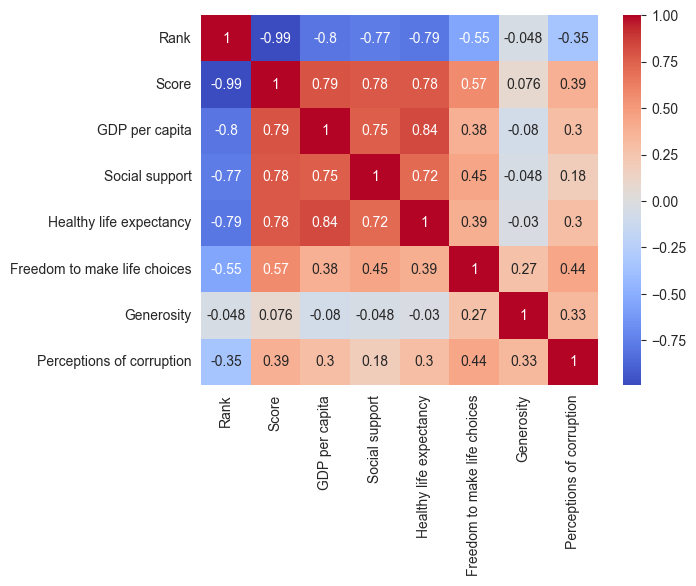

In [ ]:
# Which factor correlates most strongly with Score?
corr=df.corr(numeric_only=True)
sns.heatmap(corr, annot=True,cmap='coolwarm')
#GDP per capita higly(0.79) corelate to score 
#Social support and Healthy life expectancy both (0.78) to score 


In [ ]:
# Which factor has the weakest correlation with happiness score?
# Generosity(with 0.076) is the weakest that contributed in the happiness score 

In [ ]:
# What is the average happiness score by region? 
#Taking Region Columns from 2015.csv
df_15_region = pd.read_csv('2015.csv')[['Country', 'Region']]
df_merged=pd.merge(df,df_15_region,on='Country',how='left')


In [522]:
score_by_region=df_merged.groupby('Region')['Score'].mean()
score_by_region

Region
Australia and New Zealand          7.267500
Central and Eastern Europe         5.571786
Eastern Asia                       5.688833
Latin America and Caribbean        5.942550
Middle East and Northern Africa    5.237000
North America                      7.085000
Southeastern Asia                  5.273667
Southern Asia                      4.526857
Sub-Saharan Africa                 4.314611
Western Europe                     6.898400
Name: Score, dtype: float64

In [ ]:
# Find the country with the highest GDP per capita — is it also the happiest?
max_gdp=df.loc[df['GDP per capita'].idxmax()]
max_gdp[['Rank','Country','GDP per capita','Score']]

Rank                 29
Country           Qatar
GDP per capita    1.684
Score             6.374
Name: 28, dtype: object

In [524]:
# Find the country with the highest Social Support score.
max_ss=df.loc[df['Social support'].idxmax()]
max_ss[['Rank','Country','Social support']]

Rank                    4
Country           Iceland
Social support      1.624
Name: 3, dtype: object

4. Multi-Year Analysis (2015–2019)

In [ ]:
# Cleaning All the files before ConCat
df_15=pd.read_csv('2015.csv')
df_15.isnull().sum()
df_15.duplicated().sum()
df_15.columns
df_15.shape

(158, 12)

In [ ]:
df_16=pd.read_csv('2016.csv')
df_16.isnull().sum()
df_16.duplicated().sum()
df_16.columns
df_16.shape#(157,13)

In [ ]:
df_17=pd.read_csv('2017.csv')
df_17.isnull().sum()#0
df_17.duplicated().sum()#0
df_17.columns
df_17.shape#(155,12)

In [ ]:
df_18=pd.read_csv('2018.csv')
df_18.isnull().sum()#1
# df_18['Perceptions of corruption']=df_18['Perceptions of corruption'].fillna(df_18['Perceptions of corruption'].mean())
df_18.isnull().sum()#0
df_18.duplicated().sum()#0
df_18.shape

In [ ]:
# Renames columns to standard format and the Concat 
files = {'2015.csv': {'Happiness Rank':'Rank','Happiness Score':'Score','Economy (GDP per Capita)':'GDP per capita','Freedom':'Freedom to make life choices','Trust (Government Corruption)':'Perceptions of corruption','Family':'Social support','Health (Life Expectancy)':'Healthy life expectancy'}, 
    '2016.csv': {'Happiness Rank':'Rank','Happiness Score':'Score','Economy (GDP per Capita)':'GDP per capita','Freedom':'Freedom to make life choices','Trust (Government Corruption)':'Perceptions of corruption','Health (Life Expectancy)':'Healthy life expectancy','Family':'Social support'},
        '2017.csv':{'Happiness.Rank':'Rank','Happiness.Score':'Score','Economy..GDP.per.Capita.':'GDP per capita','Freedom':'Freedom to make life choices','Trust..Government.Corruption.':'Perceptions of corruption','Health..Life.Expectancy.':'Healthy life expectancy','Family':'Social support','Dystopia.Residual':'Dystopia Residual'},
            '2018.csv':{'Overall rank':'Rank','Country or region':'Country',},
            '2019.csv':{'Overall rank':'Rank','Country or region':'Country'}}
dfs = []
for file, rename_map in files.items():
    d = pd.read_csv(file).rename(columns=rename_map)
    if file=='2018.csv':
        d['Perceptions of corruption']=d['Perceptions of corruption'].fillna(d['Perceptions of corruption'].mean())
    d['Year'] = int(file[:4])
    dfs.append(d)
df_all = pd.concat(dfs, ignore_index=True)
df_all

,Country,Region,Rank,Score,Standard Error,GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Perceptions of corruption,Generosity,Dystopia Residual,Year,Lower Confidence Interval,Upper Confidence Interval,Whisker.high,Whisker.low
0,Switzerland,Western Europe,1,7.587,0.03411,1.39651,1.34951,0.94143,0.66557,0.41978,0.29678,2.51738,2015,NaN,NaN,NaN,NaN
1,Iceland,Western Europe,2,7.561,0.04884,1.30232,1.40223,0.94784,0.62877,0.14145,0.43630,2.70201,2015,NaN,NaN,NaN,NaN
2,Denmark,Western Europe,3,7.527,0.03328,1.32548,1.36058,0.87464,0.64938,0.48357,0.34139,2.49204,2015,NaN,NaN,NaN,NaN
3,Norway,Western Europe,4,7.522,0.03880,1.45900,1.33095,0.88521,0.66973,0.36503,0.34699,2.46531,2015,NaN,NaN,NaN,NaN
4,Canada,North America,5,7.427,0.03553,1.32629,1.32261,0.90563,0.63297,0.32957,0.45811,2.45176,2015,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
777,Rwanda,NaN,152,3.334,NaN,0.35900,0.71100,0.61400,0.55500,0.41100,0.21700,NaN,2019,NaN,NaN,NaN,NaN
778,Tanzania,NaN,153,3.231,NaN,0.47600,0.88500,0.49900,0.41700,0.14700,0.27600,NaN,2019,NaN,NaN,NaN,NaN
779,Afghanistan,NaN,154,3.203,NaN,0.35000,0.51700,0.36100,0.00000,0.02500,0.15800,NaN,2019,NaN,NaN,NaN,NaN
780,Central African Republic,NaN,155,3.083,NaN,0.02600,0.00000,0.10500,0.22500,0.03500,0.23500,NaN,2019,NaN,NaN,NaN,NaN


In [533]:
# How has the average global happiness score changed from 2015 to 2019?
avg_happiness_score_year=df_all.groupby('Year')['Score'].mean()
avg_happiness_score_year

Year
2015    5.375734
2016    5.382185
2017    5.354019
2018    5.375917
2019    5.407096
Name: Score, dtype: float64

In [534]:
# Pick any 3 countries — track their happiness score over 5 years. Did they improve or decline?
countries=['Finland','Denmark','India']
selected_country=df_all[df_all['Country'].isin(countries)]

trend=selected_country.pivot_table(index='Year',columns='Country',values='Score',aggfunc='mean')
trend

# Denmark-moderd slightly improve
# Finland=Slight increase
# India=dropped significantly

Country,Denmark,Finland,India
Year,,,
2015,7.527,7.406,4.565
2016,7.526,7.413,4.404
2017,7.522,7.469,4.315
2018,7.555,7.632,4.190
2019,7.600,7.769,4.015


In [535]:
# Which country had the biggest improvement in happiness score from 2015 to 2019?
pivot=df_all.pivot_table(index='Country',columns='Year',values='Score')
pivot['Improvement']=pivot[2019] - pivot[2015]
pivot.sort_values('Improvement',ascending=False).head(1)

Year,2015,2016,2017,2018,2019,Improvement
Country,,,,,,
Benin,3.34,3.484,3.657,4.141,4.883,1.543


In [536]:
# Which country had the biggest decline?
pivot.sort_values('Improvement',ascending=True).head(1)

Year,2015,2016,2017,2018,2019,Improvement
Country,,,,,,
Venezuela,6.81,6.084,5.25,4.806,4.707,-2.103


5. Visualizations

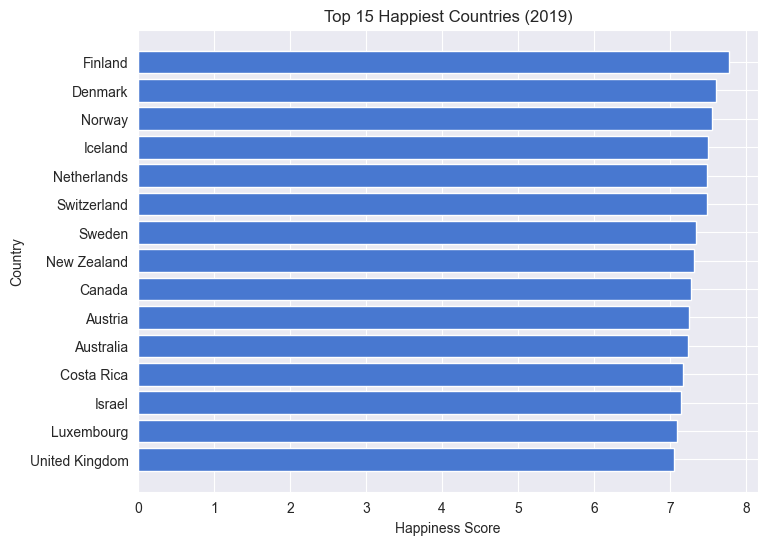

In [537]:
# Horizontal bar chart — top 15 happiest countries (2019).
top_15 = df.nlargest(15, columns='Score').sort_values('Score')
plt.figure(figsize=(8,6))
plt.barh(top_15['Country'],top_15['Score'],)
plt.xlabel('Happiness Score')
plt.ylabel('Country')
plt.title('Top 15 Happiest Countries (2019)')
plt.show()


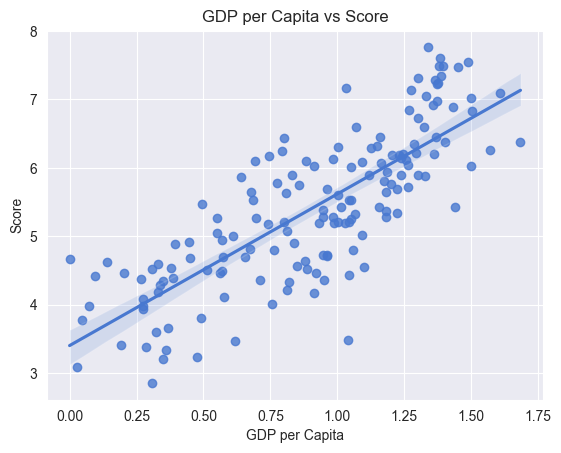

In [538]:
# Scatter plot — GDP per Capita vs Score. Add a regression line using sns.regplot.
sns.regplot(df,x='GDP per capita',y='Score')
plt.xlabel('GDP per Capita')
plt.ylabel('Score')
plt.title('GDP per Capita vs Score')
plt.show()

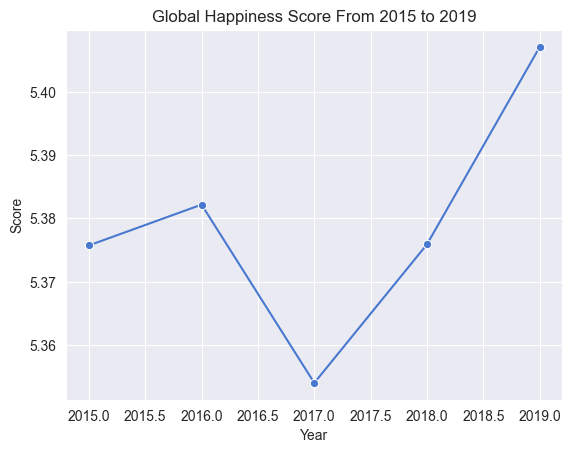

In [539]:
# Line chart — average global happiness score from 2015 to 2019.
sns.lineplot(avg_happiness_score_year,marker='o')
plt.xlabel('Year')
plt.ylabel('Score')
plt.title('Global Happiness Score From 2015 to 2019')
plt.show()

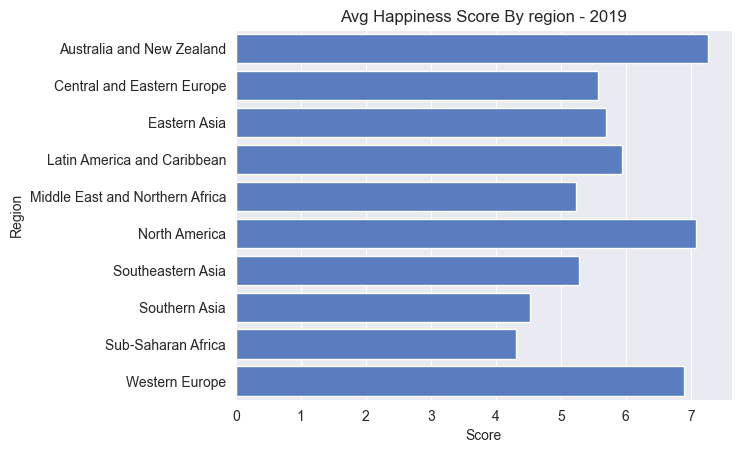

In [540]:
# Bar chart — average happiness score by region (from merged df).  
sns.barplot(score_by_region,orient='h')  
plt.xlabel('Score')
plt.ylabel('Region')
plt.title('Avg Happiness Score By region - 2019')
plt.show()